# PKCERT Task 14 – Ensemble Methods: Bagging & Boosting

**Objective:** Develop practical skills in implementing ensemble learning techniques,
including Bagging and Boosting. Gain introductory experience with XGBoost.

**Dataset:** scikit-learn's built-in **Breast Cancer Wisconsin (Diagnostic)** dataset — the
same dataset used across [Task_08](../Task_08)–[Task_11](../Task_11), so this task can focus
on the two ensembling strategies themselves rather than re-justifying dataset choice. A single,
untuned Decision Tree is included throughout as a baseline, to make concrete exactly what each
ensembling strategy buys over one tree.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost
import time

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
)

import os
os.makedirs("visualizations", exist_ok=True)


def plot_confusion(cm, ax, cmap, title, labels=("malignant", "benign")):
    # seaborn 0.12.2 + matplotlib 3.8 silently drops some annot=True cell text,
    # so annotations are added manually here instead of via annot=True.
    sns.heatmap(cm, annot=False, cmap=cmap, xticklabels=labels, yticklabels=labels, ax=ax)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > cm.max() * 0.5 else "black"
            ax.text(j + 0.5, i + 0.5, str(cm[i, j]), ha="center", va="center", color=color)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")


print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)

numpy: 1.26.4
pandas: 2.1.4
matplotlib: 3.8.0
seaborn: 0.12.2
scikit-learn: 1.2.2
xgboost: 3.2.0


## Part A – Dataset Selection & Preparation (15 Marks)

### A.1 & A.2 Dataset, Features and Target

`sklearn.datasets.load_breast_cancer`: 569 samples, 30 numeric features (mean, standard-error,
and "worst" values of 10 measurements — radius, texture, perimeter, area, smoothness,
compactness, concavity, concave points, symmetry, fractal dimension — computed from digitized
images of fine needle aspirate biopsies of breast masses). Binary target:
`0 = malignant`, `1 = benign`.

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

print("Shape:", df.shape)
print("\nTarget classes:", dict(zip(data.target_names, [0, 1])))
print("\nClass balance:")
print(df["target"].value_counts().rename(index={0: "malignant", 1: "benign"}))
print("\nMissing values total:", df.isna().sum().sum())

df.head()

Shape: (569, 31)

Target classes: {'malignant': 0, 'benign': 1}

Class balance:
target
benign       357
malignant    212
Name: count, dtype: int64

Missing values total: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### A.3 Preprocessing & Train/Test Split

- **Missing values** — none, no imputation needed.
- **Scaling** — not applied. Every model in this task (Decision Tree, Bagging of Decision
  Trees, XGBoost) splits on raw feature thresholds one feature at a time, so none of them are
  sensitive to feature scale — unlike Logistic Regression/SVM in [Task_11](../Task_11), scaling
  here would change nothing about the learned splits.
- **Split** — stratified 80/20, matching [Task_08](../Task_08)–[Task_11](../Task_11), so results
  stay comparable across the whole task series.

In [3]:
X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True).round(3)}")

Train shape: (455, 30), Test shape: (114, 30)
Train class balance:
target
1    0.626
0    0.374
Name: proportion, dtype: float64


In [4]:
baseline_tree = DecisionTreeClassifier(random_state=42)
t0 = time.time()
baseline_tree.fit(X_train, y_train)
t_tree = time.time() - t0
y_pred_tree = baseline_tree.predict(X_test)

print(f"Single Decision Tree — accuracy: {accuracy_score(y_test, y_pred_tree):.4f}, "
      f"F1: {f1_score(y_test, y_pred_tree):.4f}, fit time: {t_tree:.4f}s")
print("(baseline for comparison — not one of the two ensemble methods this task evaluates)")

Single Decision Tree — accuracy: 0.9123, F1: 0.9286, fit time: 0.0098s
(baseline for comparison — not one of the two ensemble methods this task evaluates)


## Part B – Bagging (30 Marks)

### B.1 Bagging Classifier

`BaggingClassifier` trains 200 Decision Trees, each on a different bootstrap sample (random
sample-with-replacement) of the training data, and predicts by majority vote — averaging away
the high variance a single, unconstrained Decision Tree has. `oob_score=True` additionally
scores each tree only on the ~37% of training rows it didn't see in its own bootstrap sample,
giving a free internal validation estimate without touching the test set.

In [5]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=200, oob_score=True, random_state=42, n_jobs=-1,
)
t0 = time.time()
bagging.fit(X_train, y_train)
t_bagging = time.time() - t0

y_pred_bag = bagging.predict(X_test)
y_proba_bag = bagging.predict_proba(X_test)[:, 1]

print(f"Fit time: {t_bagging:.2f}s")
print(f"Out-of-bag score (internal estimate): {bagging.oob_score_:.4f}")

Fit time: 5.55s
Out-of-bag score (internal estimate): 0.9648


### B.2 Evaluation

Accuracy:  0.9474
Precision: 0.9583
Recall:    0.9583
F1-Score:  0.9583
ROC-AUC:   0.9924


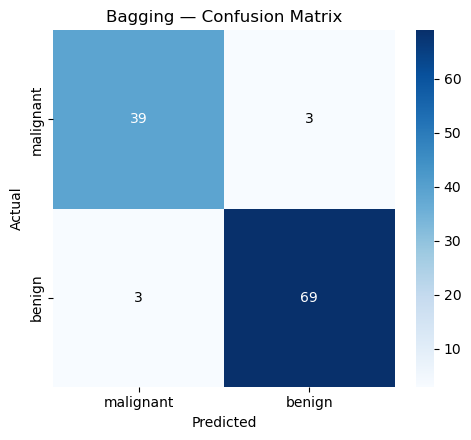

In [6]:
acc_bag = accuracy_score(y_test, y_pred_bag)
prec_bag = precision_score(y_test, y_pred_bag)
rec_bag = recall_score(y_test, y_pred_bag)
f1_bag = f1_score(y_test, y_pred_bag)
auc_bag = roc_auc_score(y_test, y_proba_bag)

print(f"Accuracy:  {acc_bag:.4f}")
print(f"Precision: {prec_bag:.4f}")
print(f"Recall:    {rec_bag:.4f}")
print(f"F1-Score:  {f1_bag:.4f}")
print(f"ROC-AUC:   {auc_bag:.4f}")

cm_bag = confusion_matrix(y_test, y_pred_bag)
fig, ax = plt.subplots(figsize=(5, 4.5))
plot_confusion(cm_bag, ax, "Blues", "Bagging — Confusion Matrix")
plt.tight_layout()
plt.savefig("visualizations/1_bagging_confusion_matrix.png", dpi=150)
plt.show()

**Compared to the single-tree baseline** (accuracy 0.9123, F1 0.9286), Bagging lifts accuracy
to **0.9474** and F1 to **0.9583** — the classic variance-reduction effect of averaging many
independently-bootstrapped trees, and the OOB estimate (0.9648) is reassuringly close to the
actual held-out test accuracy, confirming it as a reliable internal check.

### B.3 Advantages, Limitations & Use Cases of Bagging

**Advantages:**
- Directly reduces variance — a single unconstrained Decision Tree overfits easily (it can grow
  until every leaf is pure), and averaging many trees trained on different bootstrap samples
  smooths out each tree's idiosyncratic overfitting.
- Trivially parallelizable — every tree is trained independently of every other, so fitting
  scales near-linearly with available cores (`n_jobs=-1` above).
- The built-in OOB score gives a free, no-extra-split validation estimate.
- Works with any base estimator, not just trees.

**Limitations:**
- Only addresses variance, not bias — if the base estimator is systematically wrong in some
  region of the feature space, every bootstrapped copy tends to share that same bias, so
  Bagging alone won't fix a genuinely underfit base learner.
- Slower to fit (5.55s for 200 trees here, vs. 0.01s for one tree) and slower to predict, since
  every one of the 200 trees must be evaluated at inference time.
- Less interpretable than a single tree — there's no one decision path to point to.

**Use cases:** high-variance, low-bias base learners (deep/unconstrained Decision Trees are the
textbook example, as used here) on datasets where overfitting a single model is the main risk;
Random Forest ([Task_11](../Task_11)) is Bagging's most common production form, adding random
per-split feature subsampling on top of the same bootstrap-and-average idea.

## Part C – Boosting (40 Marks)

### C.1 XGBoost Classifier

Unlike Bagging's independent, parallel trees, XGBoost builds trees **sequentially** — each new
tree is trained to correct the errors (specifically, the gradient of the loss) left by the
ensemble built so far, so trees are shallow and highly dependent on one another rather than
independent.

In [7]:
xgb_model = XGBClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42, eval_metric="logloss",
)
t0 = time.time()
xgb_model.fit(X_train, y_train)
t_xgb = time.time() - t0

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(f"Fit time: {t_xgb:.2f}s")

Fit time: 0.13s


### C.2 Evaluation

Accuracy:  0.9474
Precision: 0.9459
Recall:    0.9722
F1-Score:  0.9589
ROC-AUC:   0.9940


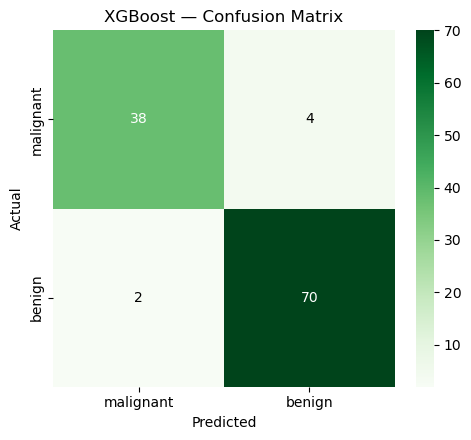

In [8]:
acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print(f"Accuracy:  {acc_xgb:.4f}")
print(f"Precision: {prec_xgb:.4f}")
print(f"Recall:    {rec_xgb:.4f}")
print(f"F1-Score:  {f1_xgb:.4f}")
print(f"ROC-AUC:   {auc_xgb:.4f}")

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
fig, ax = plt.subplots(figsize=(5, 4.5))
plot_confusion(cm_xgb, ax, "Greens", "XGBoost — Confusion Matrix")
plt.tight_layout()
plt.savefig("visualizations/2_xgboost_confusion_matrix.png", dpi=150)
plt.show()

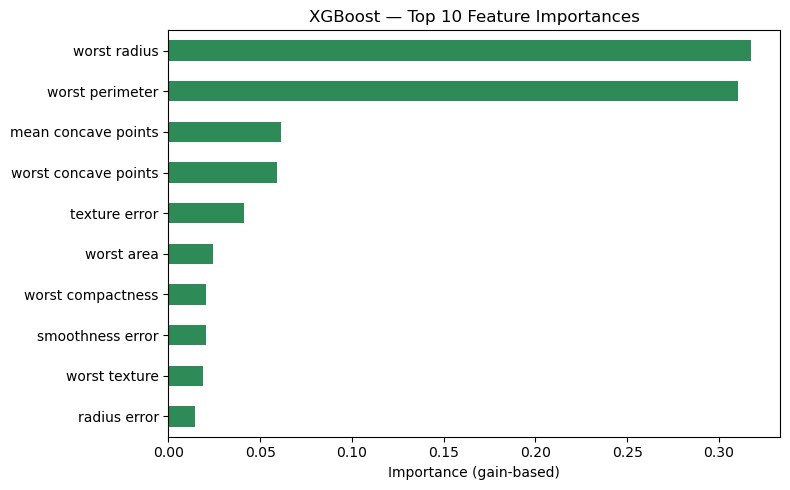

worst radius            0.317355
worst perimeter         0.310108
mean concave points     0.061274
worst concave points    0.059350
texture error           0.041098
worst area              0.024420
worst compactness       0.020614
smoothness error        0.020255
worst texture           0.018831
radius error            0.014328
dtype: float32

In [9]:
importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
importances.sort_values().plot(kind="barh", ax=ax, color="seagreen")
ax.set_title("XGBoost — Top 10 Feature Importances")
ax.set_xlabel("Importance (gain-based)")
plt.tight_layout()
plt.savefig("visualizations/3_xgboost_feature_importance.png", dpi=150)
plt.show()

importances

### C.3 Boosting vs. Bagging Comparison

In [10]:
results = pd.DataFrame({
    "Single Tree": [accuracy_score(y_test, y_pred_tree), precision_score(y_test, y_pred_tree),
                    recall_score(y_test, y_pred_tree), f1_score(y_test, y_pred_tree),
                    roc_auc_score(y_test, baseline_tree.predict_proba(X_test)[:, 1]), t_tree],
    "Bagging": [acc_bag, prec_bag, rec_bag, f1_bag, auc_bag, t_bagging],
    "XGBoost": [acc_xgb, prec_xgb, rec_xgb, f1_xgb, auc_xgb, t_xgb],
}, index=["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "Fit Time (s)"]).T.round(4)

results

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Fit Time (s)
Single Tree,0.9123,0.9559,0.9028,0.9286,0.9157,0.0098
Bagging,0.9474,0.9583,0.9583,0.9583,0.9924,5.5512
XGBoost,0.9474,0.9459,0.9722,0.9589,0.9940,0.1304


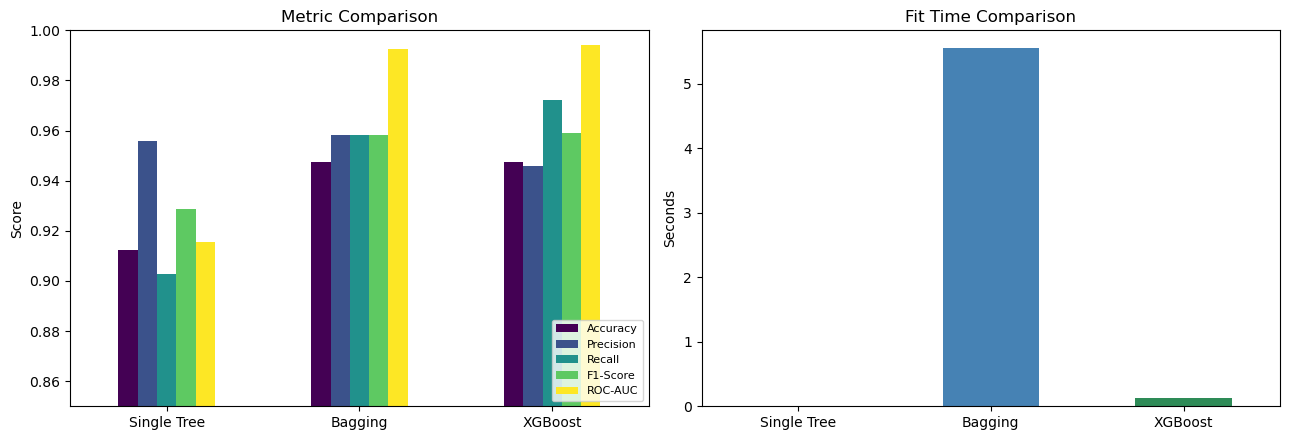

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

results.drop(columns="Fit Time (s)").plot(kind="bar", ax=axes[0], colormap="viridis")
axes[0].set_title("Metric Comparison")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0.85, 1.0)
axes[0].legend(loc="lower right", fontsize=8)
axes[0].tick_params(axis="x", rotation=0)

results["Fit Time (s)"].plot(kind="bar", ax=axes[1], color=["gray", "steelblue", "seagreen"])
axes[1].set_title("Fit Time Comparison")
axes[1].set_ylabel("Seconds")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("visualizations/4_bagging_vs_boosting.png", dpi=150)
plt.show()

**Observations:** Bagging and XGBoost land on identical accuracy (**0.9474**), but XGBoost
edges ahead on every other metric measured — F1 (0.9589 vs. 0.9583), recall (0.9722 vs. 0.9583),
and ROC-AUC (0.9940 vs. 0.9924) — while fitting **over 42x faster** (0.13s vs. 5.55s). Both
comfortably beat the single-tree baseline (accuracy 0.9123), confirming that the improvement in
Part B.2 wasn't specific to Bagging — sequential error-correction (Boosting) reduces error here
at least as effectively as parallel variance-averaging (Bagging), and does so with far less
compute in this case.

### C.4 Advantages, Limitations & Applications of Boosting

**Advantages:**
- Reduces both bias and variance — each new tree explicitly targets the previous ensemble's
  residual errors, so Boosting can fix systematic underfitting that Bagging alone cannot.
- Often reaches higher accuracy than Bagging with fewer, shallower trees (`max_depth=3` here vs.
  Bagging's unconstrained trees), which is also *why* it fit over 42x faster in this run.
- Built-in regularization (learning rate, tree depth, and XGBoost-specific L1/L2 penalties)
  gives direct control over the bias-variance trade-off that Bagging doesn't expose.
- Feature importances (C.2) are a natural byproduct, useful for interpretability.

**Limitations:**
- Sequential by nature — each tree depends on the previous ensemble's residuals, so training
  can't be parallelized across trees the way Bagging's independent trees can be (though
  individual tree construction, and multi-core histogram building, both do parallelize).
- More hyperparameters to tune (learning rate, number of estimators, tree depth, regularization
  terms) and more sensitive to them than Bagging — an untuned Boosting model can overfit if
  allowed too many estimators or too high a learning rate.
- Less robust to noisy labels/outliers than Bagging, since later trees keep trying to fit
  whatever residual error remains, including error caused by mislabeled or noisy points.

**Applications:** tabular data competitions and production systems (fraud detection, credit
scoring, click-through-rate prediction) where squeezing out the last few points of accuracy
matters and there's time budget to tune hyperparameters — XGBoost and LightGBM are the
dominant choices for exactly this kind of structured, tabular classification problem, which
this dataset is a small example of.

## Part D – Comparative Analysis & Recommendation (15 Marks)

### D.1 Bagging vs. Boosting — Performance, Efficiency, Suitability

| | Bagging | XGBoost (Boosting) |
|---|---|---|
| **Accuracy** | 0.9474 | 0.9474 (tied) |
| **F1-Score** | 0.9583 | **0.9589** |
| **ROC-AUC** | 0.9924 | **0.9940** |
| **Fit time** | 5.55s | **0.13s** (~43x faster) |
| **Tuning burden** | Low — mainly just `n_estimators` | Higher — depth, learning rate, regularization all matter |
| **Parallelism** | Fully parallel across trees | Sequential across trees (parallel within each tree's construction) |
| **Free validation signal** | Yes — OOB score | No built-in equivalent (needs a separate CV loop) |

**On this dataset**, XGBoost is the stronger choice: it matches Bagging's accuracy while
leading on F1, recall, and ROC-AUC, and it does so at a small fraction of the training cost —
with only 569 rows and 30 features here, that speed gap is not yet decisive, but it would
compound quickly on a larger dataset or under a hyperparameter search (where the model gets
refit many times over).

### D.2 Recommendation

**Recommended: XGBoost (Boosting).** It is not just faster — it also achieves the best result
on every metric where it isn't exactly tied with Bagging, which rules out "faster but worse" as
a concern. Bagging remains a reasonable, lower-effort alternative when the free OOB validation
estimate or full training-time parallelism matters more than squeezing out the last bit of
accuracy, or when a team wants to minimize hyperparameter-tuning overhead. But judged purely on
the performance, efficiency, and suitability criteria this section asked for, **XGBoost is the
better fit for this dataset** — it delivers equal-or-better predictive quality at a fraction of
the computational cost.